In [ ]:
import os
import pandas as pd
import numpy as np
from pickle import load

import warnings
warnings.filterwarnings('ignore')


In [2]:
np.random.seed(42)

In [3]:
df = pd.read_csv(os.path.join('..','data', 'mimic', 'df_final_for_metadata_prediction.csv'))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200452 entries, 0 to 200451
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Unnamed: 0    200452 non-null  int64 
 1   path          200452 non-null  object
 2   subject_id    200452 non-null  int64 
 3   gender        200452 non-null  object
 4   insurance     200452 non-null  object
 5   grouped_race  200452 non-null  object
 6   age_decile    200452 non-null  object
 7   No Finding    200452 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 12.2+ MB


In [4]:
print("Absolute number of gender:\n", df["gender"].value_counts())
print("Percentage number of gender:\n", df["gender"].value_counts(normalize=True)*100)

Absolute number of gender:
 gender
M    107241
F     93211
Name: count, dtype: int64
Percentage number of gender:
 gender
M    53.499591
F    46.500409
Name: proportion, dtype: float64


In [5]:
# load embeddings
embedding_metadata_path = os.path.join("..", "data", "mimic", "cxr-foundation", "embedding_metadata.pkl")
with open(embedding_metadata_path, 'rb') as f:
    vembs, labels, ids = load(f)

In [6]:
label = labels['disease']

In [ ]:
from umap import UMAP
import matplotlib.pyplot as plt

In [8]:
# Select 1000 random indices
n_samples = min(1000, len(vembs))
random_indices = np.random.choice(len(vembs), size=n_samples, replace=False)


In [9]:
# Extract random samples
vembs_sample = vembs[random_indices]
labels_sample = label[random_indices]

print(f"Using {n_samples} samples for UMAP")

Using 1000 samples for UMAP


In [10]:
# Create directory if it doesn't exist
save_dir = '../fig/mimic/cxr-foundation'
os.makedirs(save_dir, exist_ok=True)

embedding_2d shape: (1000, 2)
labels_sample shape: (1000, 1)
labels_unique: [np.float64(0.0), np.float64(1.0)]
Label 0.0: mask shape (1000,), sum 668
Label 1.0: mask shape (1000,), sum 332


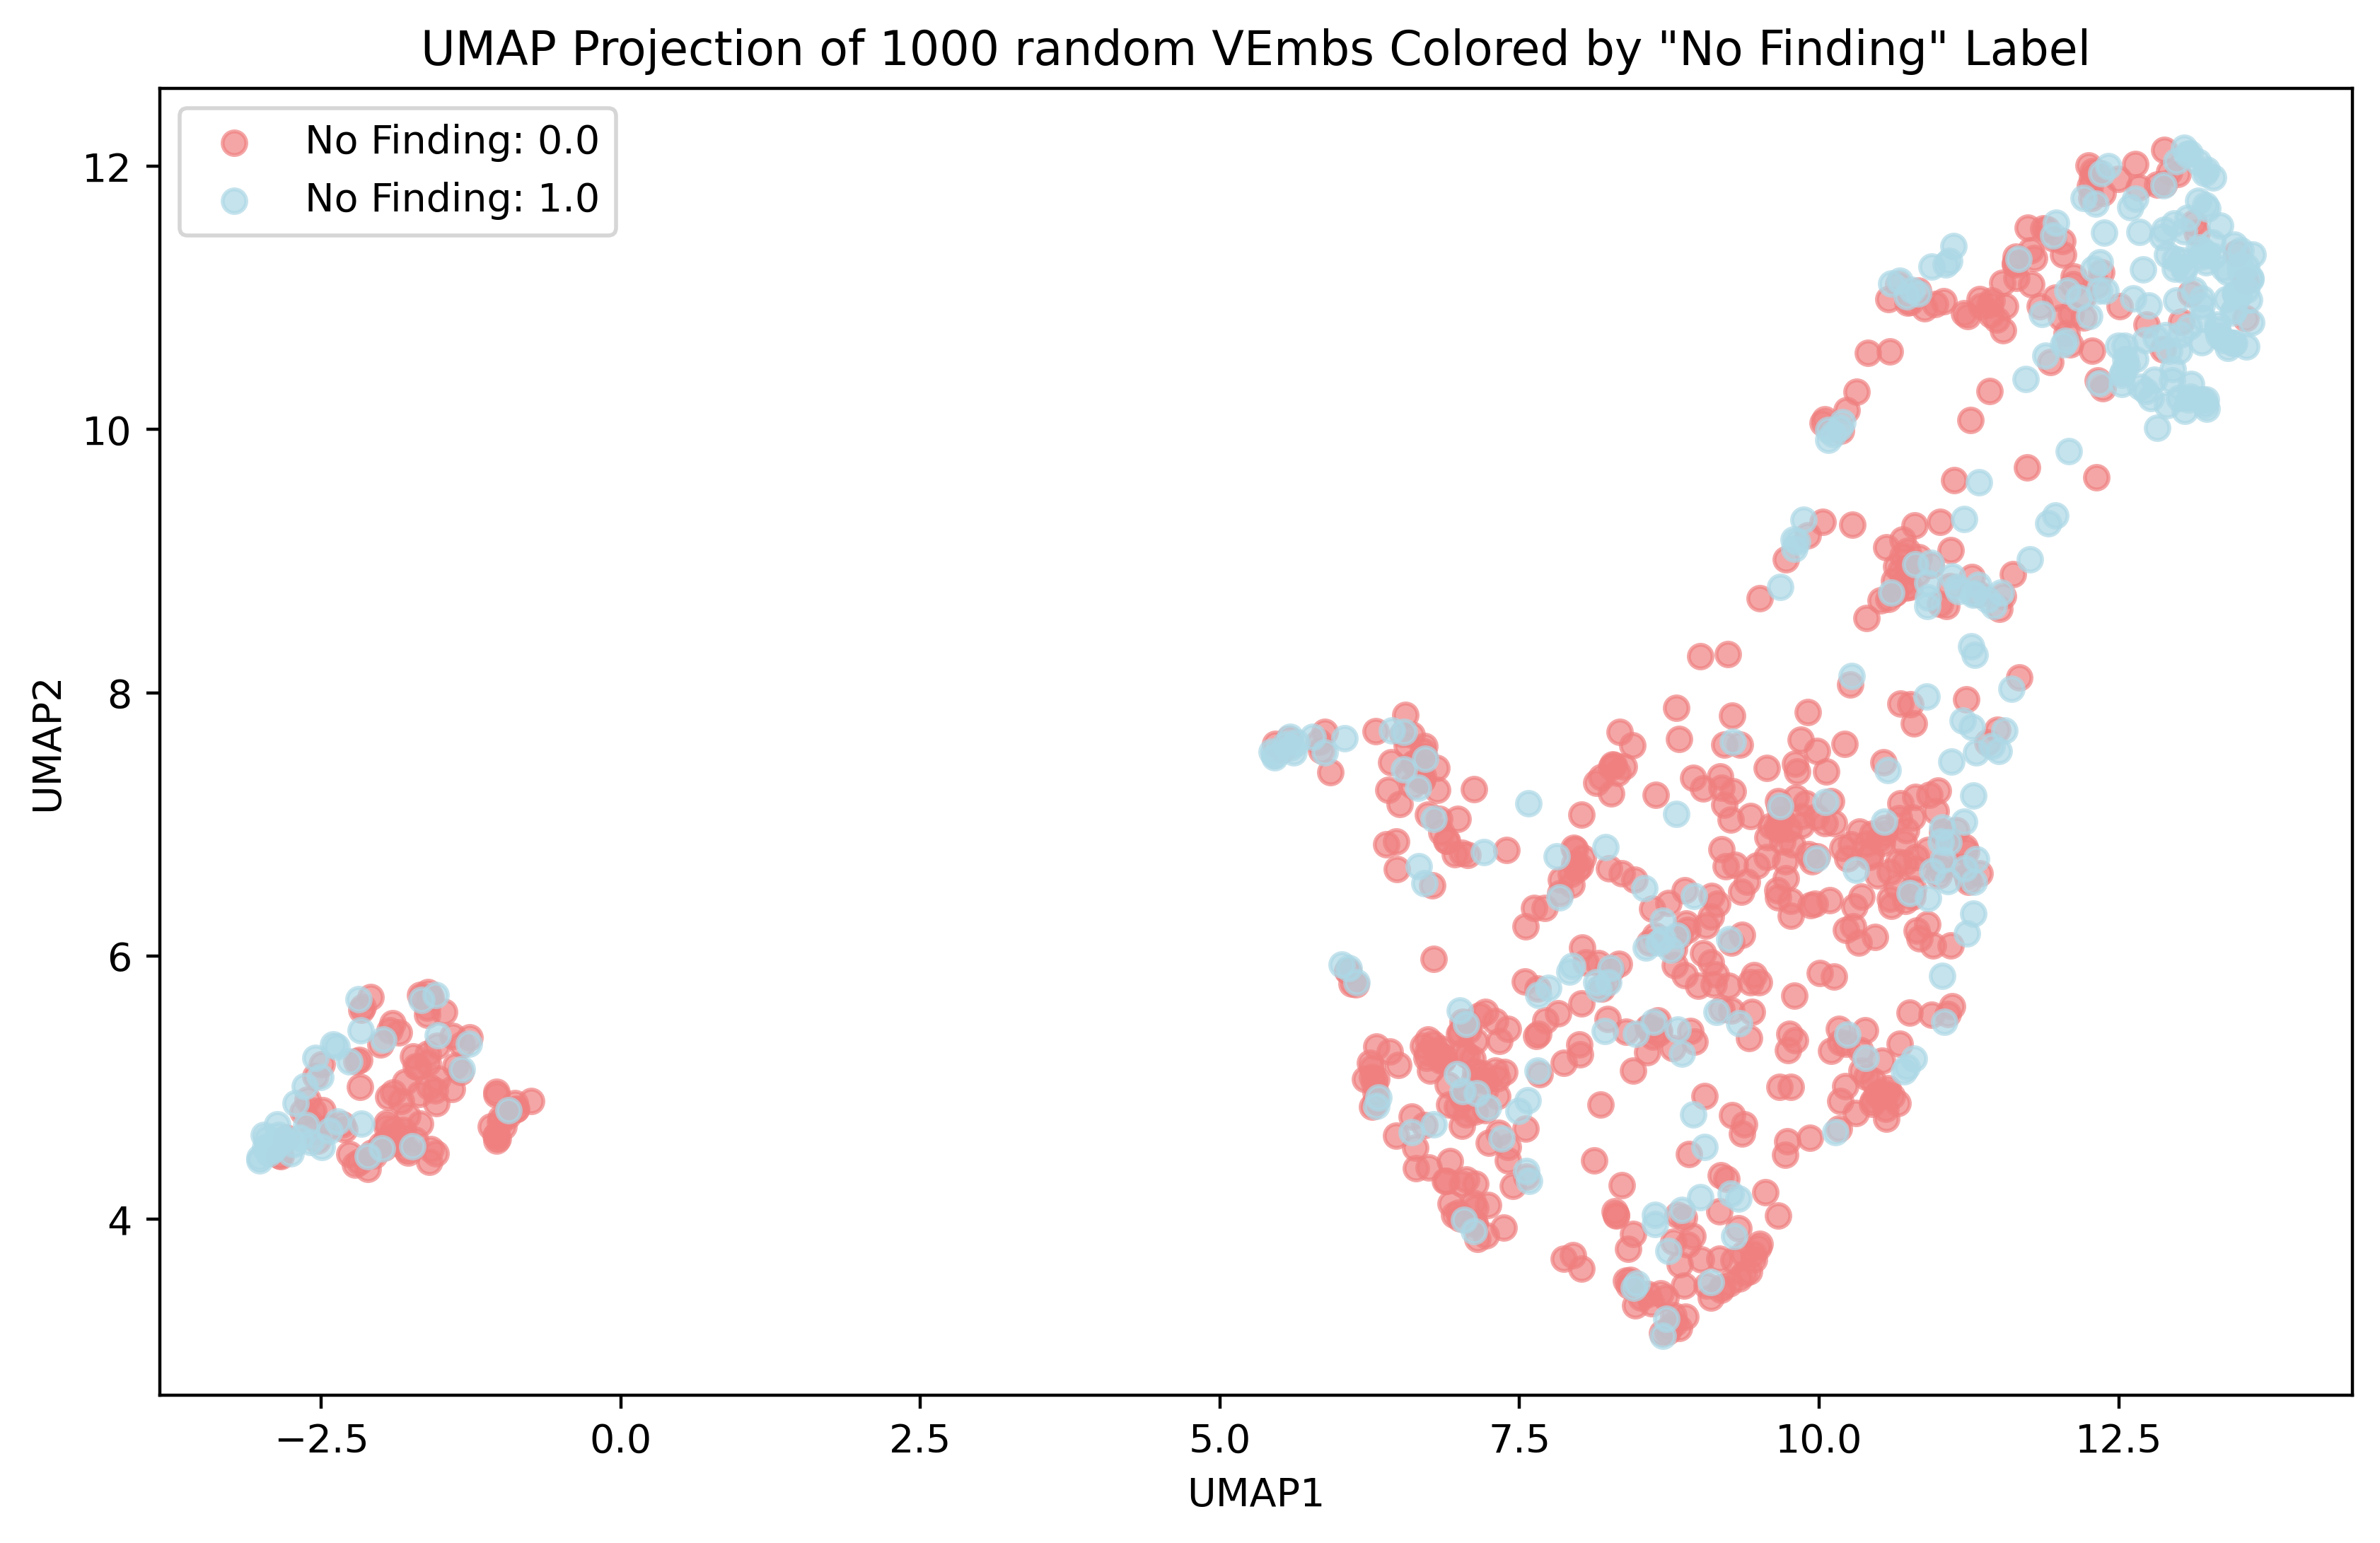

In [11]:
# compute UMAP projection
umap_model = UMAP(n_components=2, random_state=42)
embedding_2d = umap_model.fit_transform(vembs_sample)

plt.figure(figsize=(10, 6), dpi=400)

# Define colors for the two classes
colors = ['lightcoral', 'lightblue']  # light red, light blue
labels_unique = sorted(np.unique(labels_sample))

print(f"embedding_2d shape: {embedding_2d.shape}")
print(f"labels_sample shape: {labels_sample.shape}")
print(f"labels_unique: {labels_unique}")

# Create scatter plot for each class
for i, label in enumerate(labels_unique):
    mask = (labels_sample == label).flatten()  # Ensure mask is 1D
    print(f"Label {label}: mask shape {mask.shape}, sum {mask.sum()}")
    
    plt.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], 
                c=colors[i], alpha=0.7, 
                label=f'No Finding: {label}')

plt.title('UMAP Projection of 1000 random VEmbs Colored by "No Finding" Label')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend()
plt.savefig(f'{save_dir}/umap_projection.png', dpi=400, bbox_inches='tight')
plt.show()

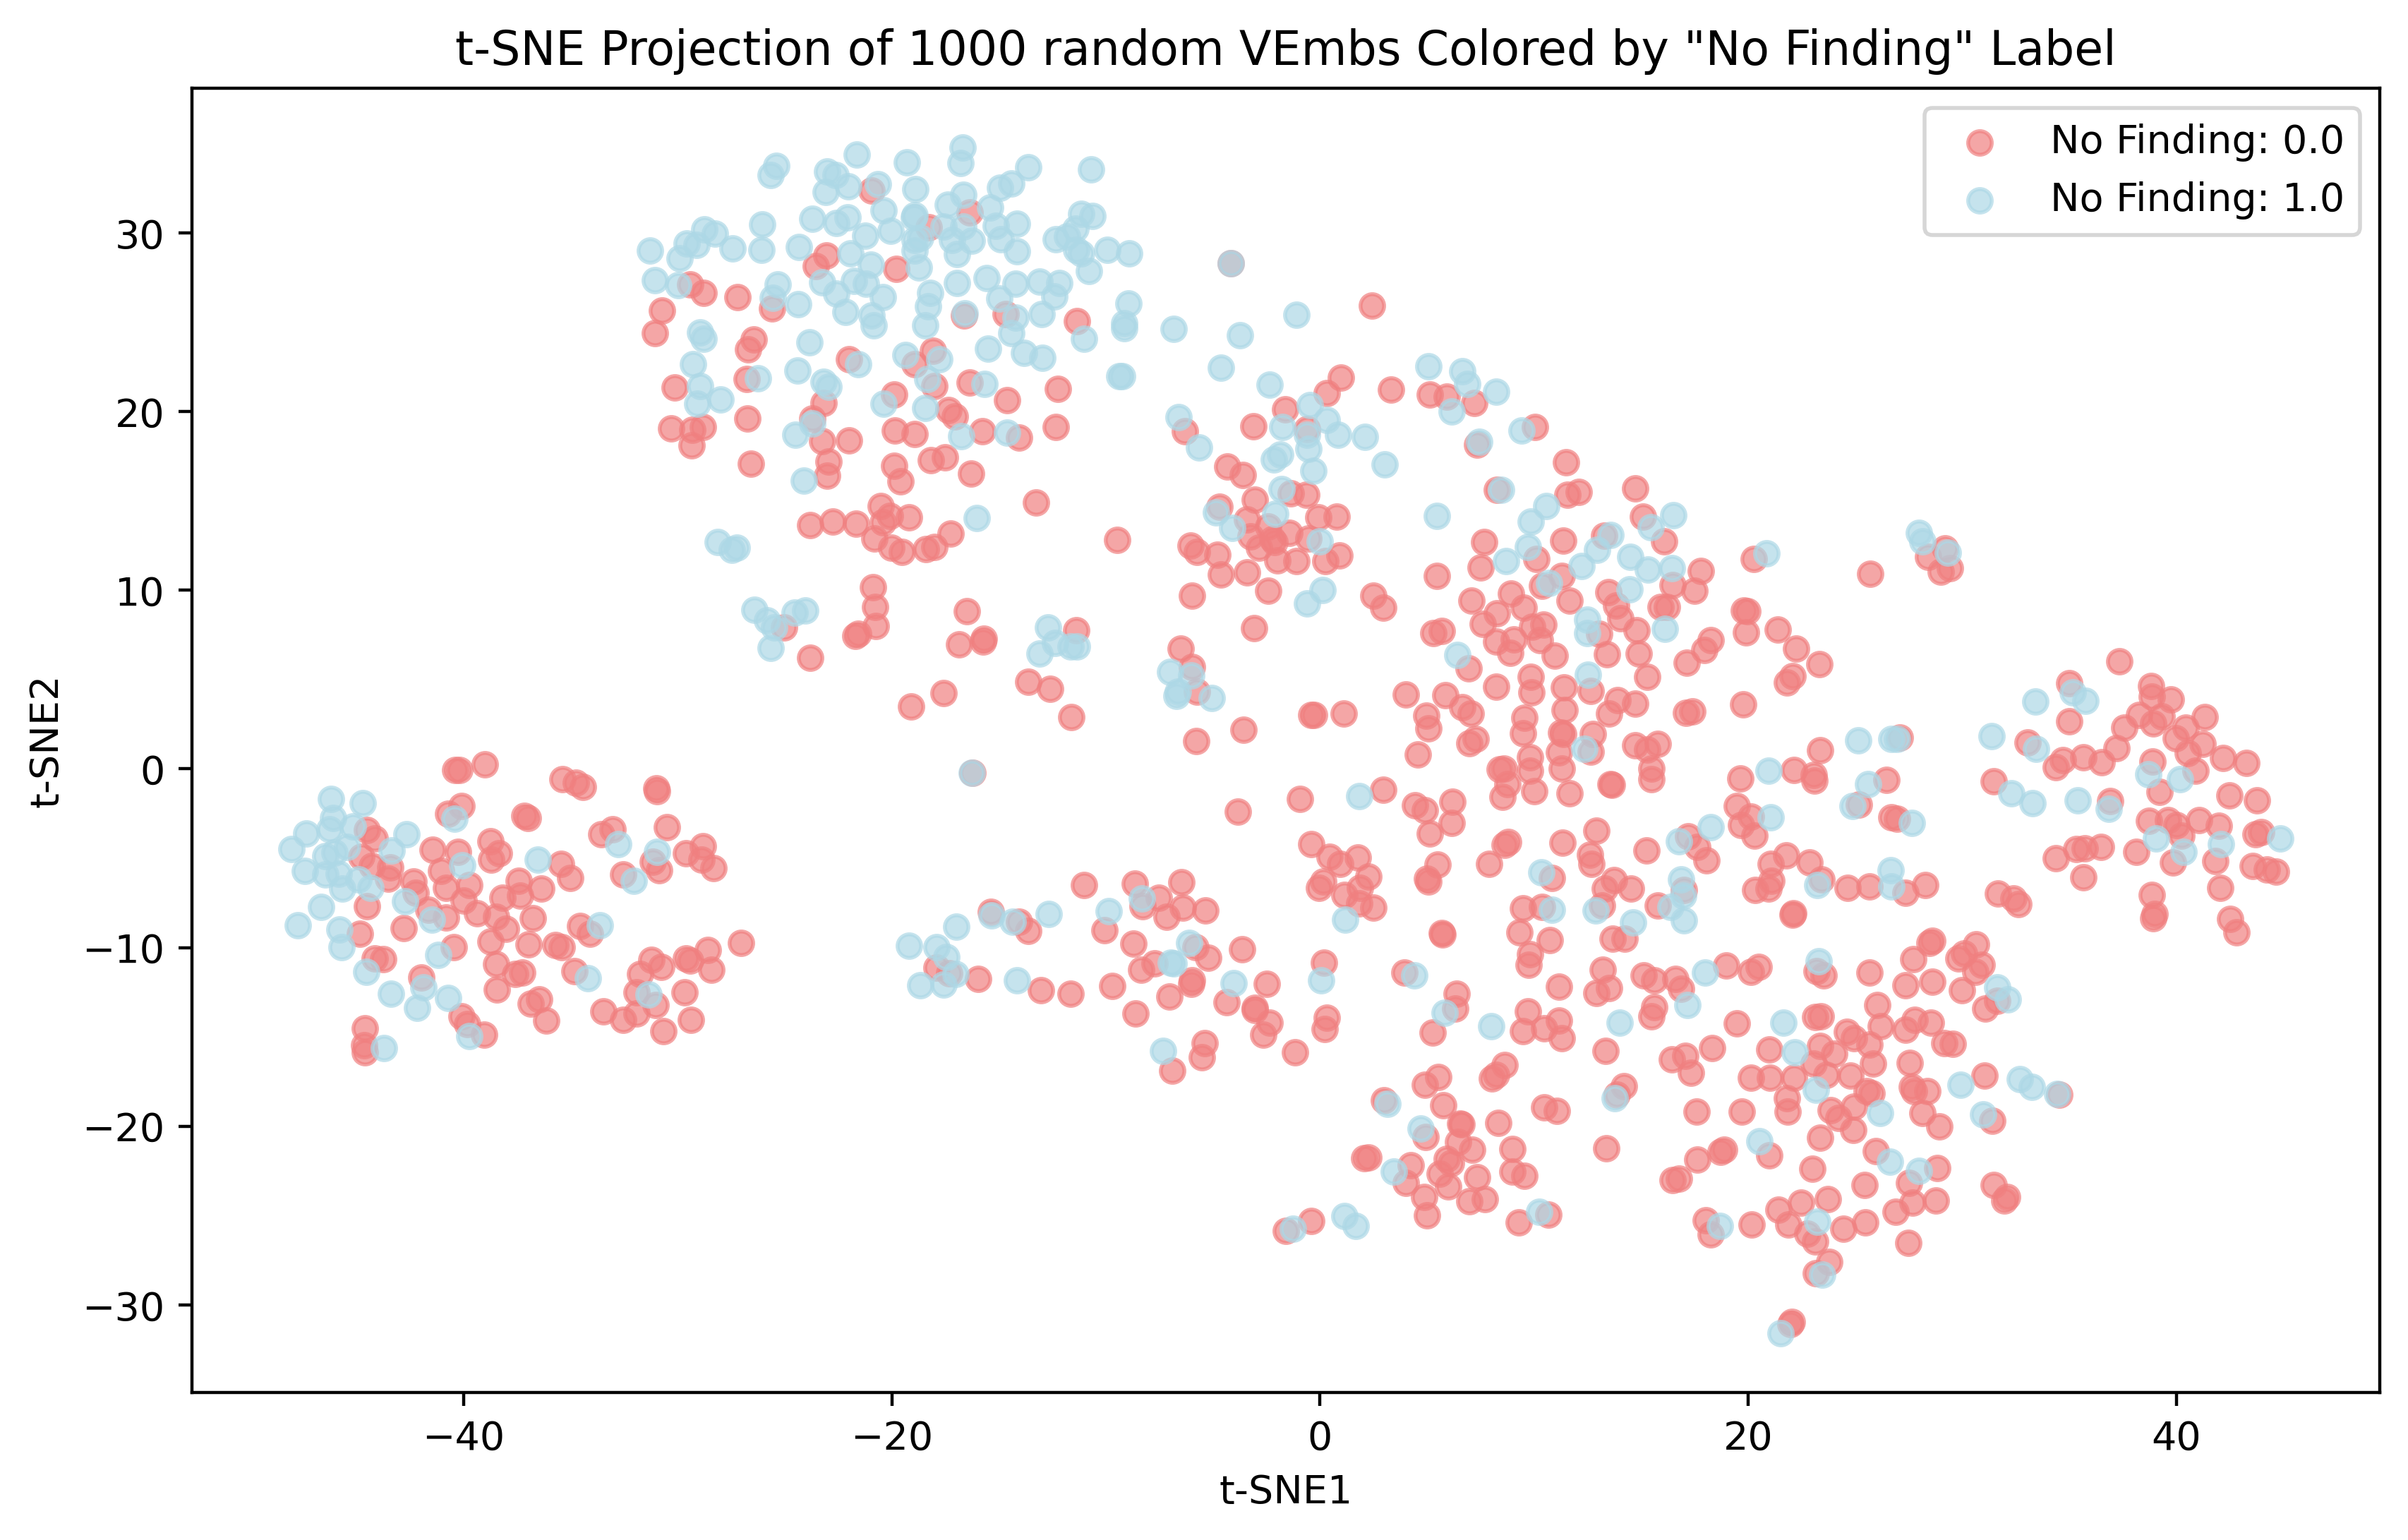

In [12]:
from sklearn.manifold import TSNE

# compute t-SNE projection
tsne_model = TSNE(n_components=2, random_state=42, perplexity=30)
embedding_2d_tsne = tsne_model.fit_transform(vembs_sample)

plt.figure(figsize=(10, 6), dpi=400)

# Create scatter plot for each class
for i, label in enumerate(labels_unique):
    mask = (labels_sample == label).flatten()  # Ensure mask is 1D
    plt.scatter(embedding_2d_tsne[mask, 0], embedding_2d_tsne[mask, 1], 
                c=colors[i], alpha=0.7, 
                label=f'No Finding: {label}')

plt.title('t-SNE Projection of 1000 random VEmbs Colored by "No Finding" Label')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.legend()
plt.savefig(f'{save_dir}/tsne_projection.png', dpi=400, bbox_inches='tight')
plt.show()

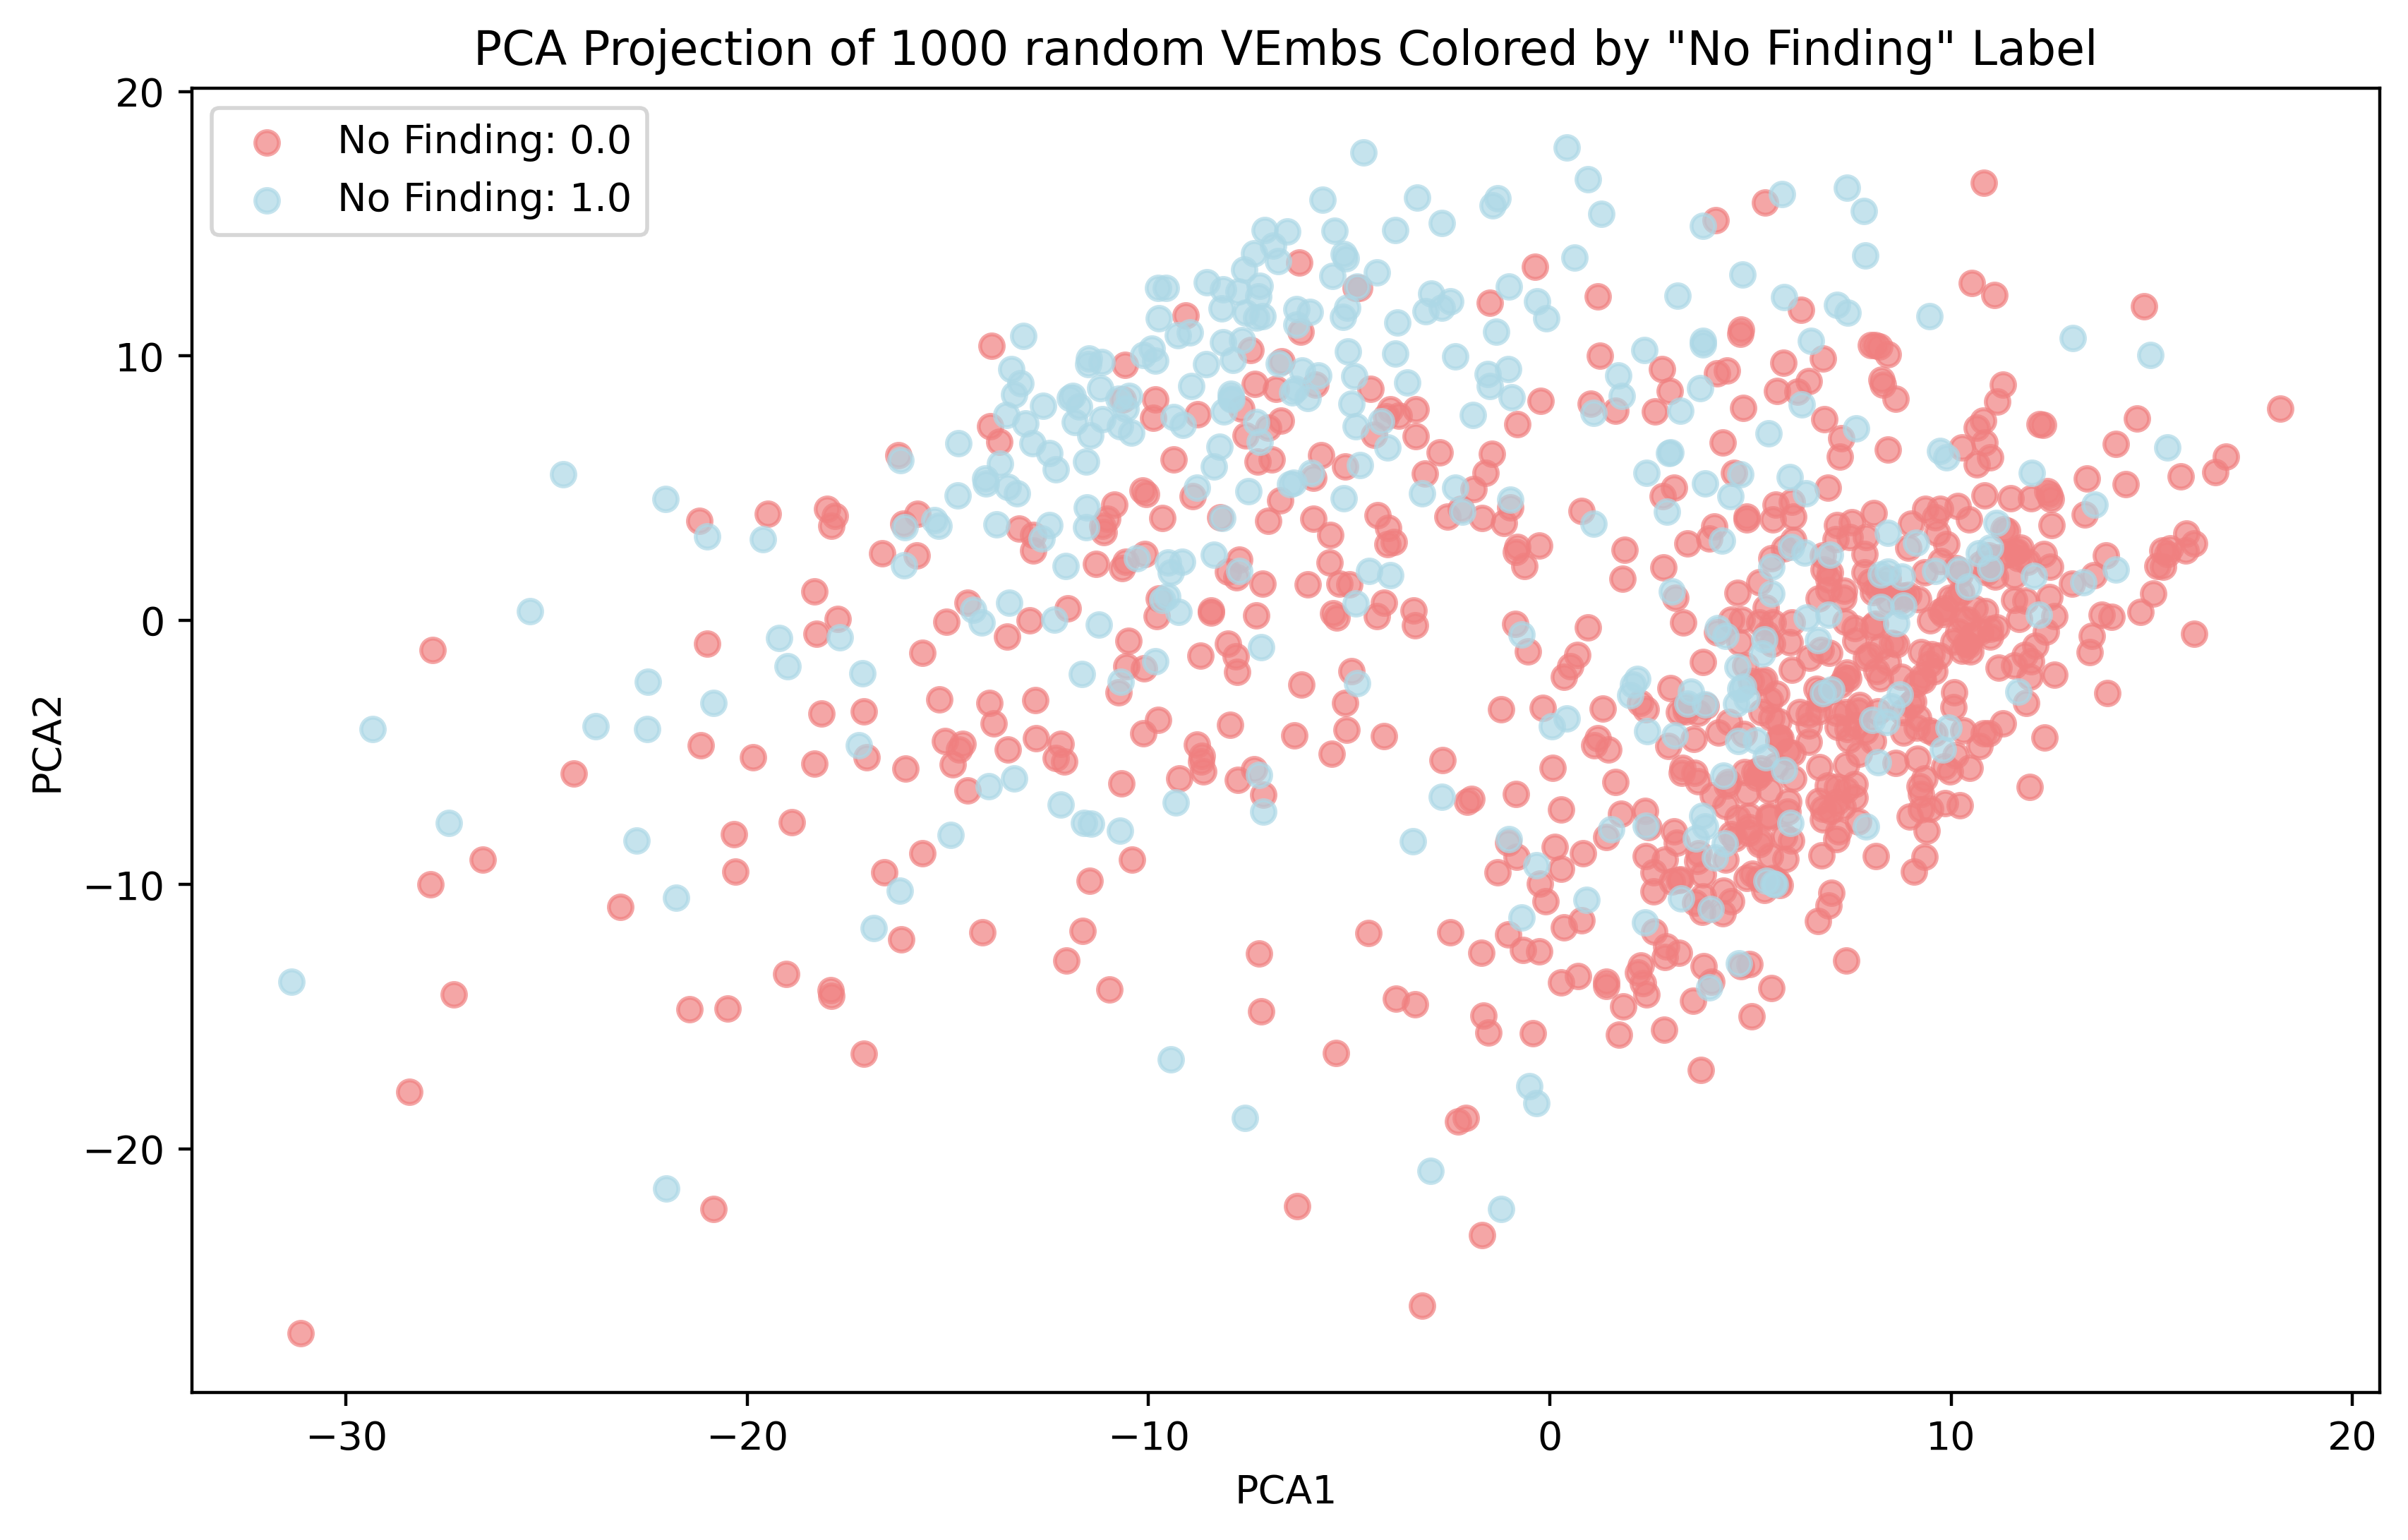

PCA Information Preservation:
PC1 explains: 0.181 (18.1%)
PC2 explains: 0.116 (11.6%)
Total variance explained: 0.298 (29.8%)


In [13]:
from sklearn.decomposition import PCA

# compute PCA projection
pca_model = PCA(n_components=2, random_state=42)
embedding_2d_pca = pca_model.fit_transform(vembs_sample)

plt.figure(figsize=(10, 6), dpi=400)

# Create scatter plot for each class
for i, label in enumerate(labels_unique):
    mask = (labels_sample == label).flatten()  # Ensure mask is 1D
    plt.scatter(embedding_2d_pca[mask, 0], embedding_2d_pca[mask, 1], 
                c=colors[i], alpha=0.7, 
                label=f'No Finding: {label}')

plt.title('PCA Projection of 1000 random VEmbs Colored by "No Finding" Label')
plt.xlabel(f'PCA1')
plt.ylabel(f'PCA2')
plt.legend()
plt.savefig(f'{save_dir}/pca_projection.png', dpi=400, bbox_inches='tight')
plt.show()

print("PCA Information Preservation:")
print(f"PC1 explains: {pca_model.explained_variance_ratio_[0]:.3f} ({pca_model.explained_variance_ratio_[0]*100:.1f}%)")
print(f"PC2 explains: {pca_model.explained_variance_ratio_[1]:.3f} ({pca_model.explained_variance_ratio_[1]*100:.1f}%)")
print(f"Total variance explained: {pca_model.explained_variance_ratio_.sum():.3f} ({pca_model.explained_variance_ratio_.sum()*100:.1f}%)")

In [14]:
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr

def compute_preservation_metrics(X_high, X_low, k=10):
    """
    Compute trustworthiness, continuity, and distance correlation
    """
    n_samples = X_high.shape[0]
    
    # Compute pairwise distances
    dist_high = pairwise_distances(X_high)
    dist_low = pairwise_distances(X_low)
    
    # 1. Distance correlation (Shepard diagram)
    # Use upper triangle to avoid duplicates
    triu_indices = np.triu_indices(n_samples, k=1)
    dist_corr, _ = pearsonr(dist_high[triu_indices], dist_low[triu_indices])
    
    # 2. Trustworthiness - are nearby points in low-D also nearby in high-D?
    trustworthiness = 0
    for i in range(n_samples):
        # k nearest neighbors in low-D
        nn_low = np.argsort(dist_low[i])[1:k+1]  # exclude self (index 0)
        # ranks of these points in high-D
        high_ranks = np.argsort(np.argsort(dist_high[i]))
        # penalty for points that are far in high-D but close in low-D
        for j in nn_low:
            rank_high = high_ranks[j]
            if rank_high > k:
                trustworthiness += rank_high - k
    
    trustworthiness = 1 - (2 / (n_samples * k * (2*n_samples - 3*k - 1))) * trustworthiness
    
    # 3. Continuity - are nearby points in high-D also nearby in low-D?
    continuity = 0
    for i in range(n_samples):
        # k nearest neighbors in high-D
        nn_high = np.argsort(dist_high[i])[1:k+1]
        # ranks of these points in low-D
        low_ranks = np.argsort(np.argsort(dist_low[i]))
        # penalty for points that are far in low-D but close in high-D
        for j in nn_high:
            rank_low = low_ranks[j]
            if rank_low > k:
                continuity += rank_low - k
    
    continuity = 1 - (2 / (n_samples * k * (2*n_samples - 3*k - 1))) * continuity
    
    return {
        'distance_correlation': dist_corr,
        'trustworthiness': trustworthiness,
        'continuity': continuity
    }

# Compute metrics for all methods
print("\n" + "="*50)
print("INFORMATION PRESERVATION METRICS")
print("="*50)

# For UMAP
metrics_umap = compute_preservation_metrics(vembs_sample, embedding_2d)
print(f"\nUMAP:")
print(f"  Distance correlation: {metrics_umap['distance_correlation']:.3f}")
print(f"  Trustworthiness: {metrics_umap['trustworthiness']:.3f}")
print(f"  Continuity: {metrics_umap['continuity']:.3f}")

# For t-SNE
metrics_tsne = compute_preservation_metrics(vembs_sample, embedding_2d_tsne)
print(f"\nt-SNE:")
print(f"  Distance correlation: {metrics_tsne['distance_correlation']:.3f}")
print(f"  Trustworthiness: {metrics_tsne['trustworthiness']:.3f}")
print(f"  Continuity: {metrics_tsne['continuity']:.3f}")

# For PCA
metrics_pca = compute_preservation_metrics(vembs_sample, embedding_2d_pca)
print(f"\nPCA:")
print(f"  Distance correlation: {metrics_pca['distance_correlation']:.3f}")
print(f"  Trustworthiness: {metrics_pca['trustworthiness']:.3f}")
print(f"  Continuity: {metrics_pca['continuity']:.3f}")
print(f"  Explained variance: {pca_model.explained_variance_ratio_.sum():.3f}")


INFORMATION PRESERVATION METRICS

UMAP:
  Distance correlation: 0.470
  Trustworthiness: 0.944
  Continuity: 0.949

t-SNE:
  Distance correlation: 0.586
  Trustworthiness: 0.963
  Continuity: 0.950

PCA:
  Distance correlation: 0.811
  Trustworthiness: 0.835
  Continuity: 0.913
  Explained variance: 0.298
